In [ ]:
import numpy as np              # Provides efficient numerical operations and array handling
import tensorflow as tf         # Used for building and running machine learning models
from pathlib import Path        # Enables platform-independent file and directory path handling
import cv2                      # OpenCV library for image processing and computer vision tasks

In [6]:
import shutil
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

# Default location inside repo (DON'T commit the dataset; keep it ignored)
DEFAULT_SOURCE = PROJECT_ROOT / "data" / "plantvillage" / "color"
DEFAULT_DEST = PROJECT_ROOT / "data" / "filtered_data"

# Allow override from environment variables (best for different machines)
SOURCE_DATASET = Path(os.getenv("PLANTVILLAGE_COLOR_DIR", str(DEFAULT_SOURCE))).expanduser().resolve()
DESTINATION_DATASET = Path(os.getenv("FILTERED_DATA_DIR", str(DEFAULT_DEST))).expanduser().resolve()

# List of folders to include
TARGET_CLASSES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Strawberry___healthy",
    "Strawberry___Leaf_scorch",
]

# Create destination
DESTINATION_DATASET.mkdir(exist_ok=True)

print("Starting dataset filtering...")

for class_name in TARGET_CLASSES:
    source_folder = SOURCE_DATASET / class_name
    dest_folder = DESTINATION_DATASET / class_name
    # Copy class folder if present in the source dataset
    if source_folder.exists():
        if not dest_folder.exists():
            print(f"📁 Copying {class_name}...")
            shutil.copytree(source_folder, dest_folder)
        else:
            print(f"{class_name} already exists in filtered set.")
    else:
        print(f"Warning: Could not find {class_name} in source!")

print("\n Filtering complete. Your 'filtered_data' folder is ready for training.")

Starting dataset filtering...
Tomato___Early_blight already exists in filtered set.
Tomato___Late_blight already exists in filtered set.
Tomato___Tomato_Yellow_Leaf_Curl_Virus already exists in filtered set.
📁 Copying Tomato___healthy...
📁 Copying Potato___Early_blight...
📁 Copying Potato___Late_blight...
📁 Copying Potato___healthy...
📁 Copying Corn_(maize)___Common_rust_...
📁 Copying Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot...
📁 Copying Corn_(maize)___Northern_Leaf_Blight...
📁 Copying Corn_(maize)___healthy...
📁 Copying Pepper,_bell___Bacterial_spot...
📁 Copying Pepper,_bell___healthy...
📁 Copying Apple___Apple_scab...
📁 Copying Apple___Black_rot...
📁 Copying Apple___Cedar_apple_rust...
📁 Copying Apple___healthy...
📁 Copying Strawberry___healthy...
📁 Copying Strawberry___Leaf_scorch...

 Filtering complete. Your 'filtered_data' folder is ready for training.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# --- Configuration ---
BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "filtered_data"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Image Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,    # 20% of data for testing accuracy
    rotation_range=25,       # Randomly rotate photos
    zoom_range=0.2,          # Randomly zoom in
    horizontal_flip=True,    # Flip images horizontally
    fill_mode="nearest"
)

# 2. Load Training Data
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# 3. Load Validation Data
val_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# 4. Save the Label Map (The index to name dictionary)
NUM_CLASSES = train_data.num_classes
labels = train_data.class_indices
with open("new_label_map.txt", "w") as f:
    for name, index in labels.items():
        f.write(f"{index}:{name}\n")

print(f"Setup complete! Found {NUM_CLASSES} classes across your selected crops.")

In [4]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights to give "extra attention" to rare diseases
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras import layers, models

# 1. Load the pre-trained MobileNetV2 (without the top classification layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, 
    weights="imagenet"
)

# 2. Freeze the base model so we don't destroy pre-trained features
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Converts 2D features to a 1D vector
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),              # Prevents overfitting
    layers.Dense(NUM_CLASSES, activation='softmax') # The output for 13 classes
])

# 3. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,803 (9.88 MB)

 Trainable params: 332,819 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
MODEL_NAME = "crop_disease_master_model.keras"

# Defining training callbacks
callbacks = [
    # Stop training early if validation loss doesn't improve
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    # Save the best model during training
    tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, save_best_only=True),
    # Reduce learning rate when a plateau in validation loss is detected
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

In [ ]:
# 4. Start the Training
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,             # Start with 15; EarlyStopping will handle the rest
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/15
326/577 ━━━━━━━━━━━━━━━━━━━━ 2:20 561ms/step - accuracy: 0.5318 - loss: 1.7526

In [ ]:
# Load the best version that was saved during training
model = tf.keras.models.load_model(MODEL_NAME)

In [ ]:
# Check the final accuracy scores
val_acc = history.history['val_accuracy'][-1]
print(f"✅ Training Complete! Validation Accuracy: {val_acc*100:.2f}%")

NameError: name 'history' is not defined

Generating predictions for 13 classes...
145/145 ━━━━━━━━━━━━━━━━━━━━ 88s 606ms/step


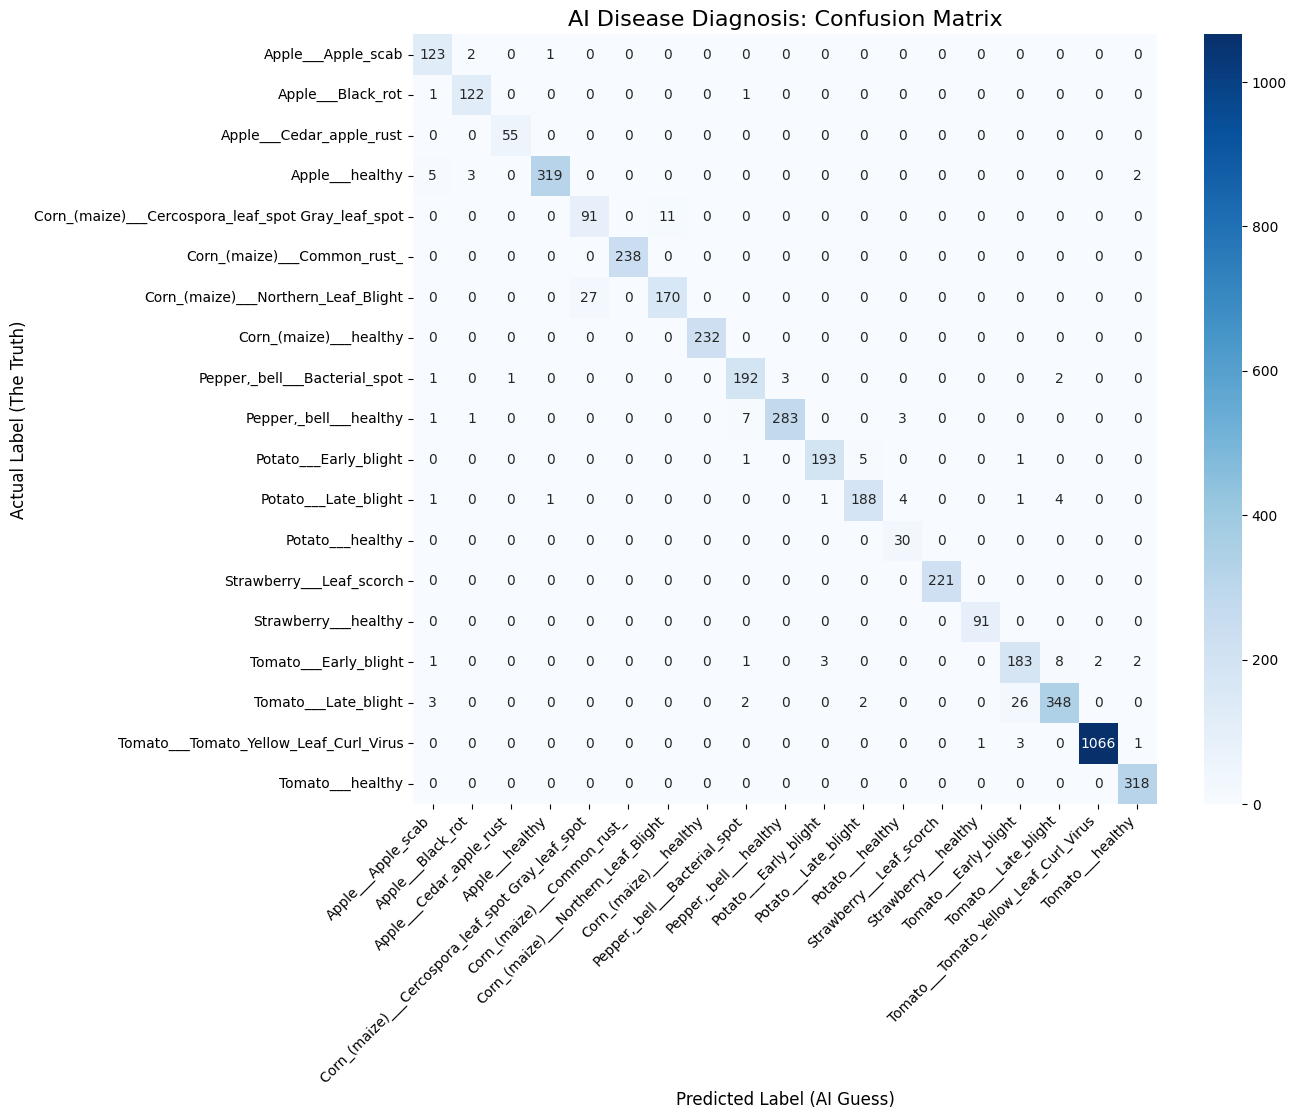


--- Detailed Classification Report ---

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.98      0.94       126
                                 Apple___Black_rot       0.95      0.98      0.97       124
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        55
                                   Apple___healthy       0.99      0.97      0.98       329
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.77      0.89      0.83       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.86      0.90       197
                            Corn_(maize)___healthy       1.00      1.00      1.00       232
                     Pepper,_bell___Bacterial_spot       0.94      0.96      0.95       199
                            Pepper,_be

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get the 'True' labels from the validation generator
# We set shuffle=False earlier so the order matches the predictions
y_true = val_data.classes 

# 2. Get the 'Predicted' labels
print("Generating predictions for 13 classes...")
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)

# 3. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Get the class names from the label map for the axis labels
class_names = list(val_data.class_indices.keys())

# 5. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('AI Disease Diagnosis: Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label (The Truth)', fontsize=12)
plt.xlabel('Predicted Label (AI Guess)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# 6. Print the text report
print("\n--- Detailed Classification Report ---\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [ ]:
model = tf.keras.models.load_model(MODEL_NAME)

dummy_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
model(dummy_input)

<tf.Tensor: shape=(1, 19), dtype=float32, numpy=
array([[1.54860842e-03, 1.53664878e-05, 4.18214186e-04, 1.95824751e-03,
        4.53287385e-06, 1.98814334e-04, 4.55455483e-05, 2.39582390e-01,
        1.06835010e-07, 8.32190744e-06, 7.61432084e-10, 8.98036831e-07,
        1.12098256e-07, 1.06537175e-06, 2.54520069e-06, 1.18108846e-05,
        7.55121052e-01, 1.08252039e-04, 9.74165858e-04]], dtype=float32)>

In [ ]:
# EPIC-4: USER STORY 11
def is_blurry(img_path, threshold: float = 100.0):
    img_path = str(img_path)
    img = cv2.imread(img_path)

    if img is None:
        # Image not found or not readable
        raise FileNotFoundError(
            f"OpenCV could not read the image at: {img_path}\n"
            f"Tip: use an absolute path or check the notebook working directory."
        )

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

In [8]:
def generate_gradcam(model, img_path, layer_name=None):
    """Generate a Grad-CAM heatmap overlay for the predicted class.

    Fixes Keras graph issues by building the Grad-CAM model using the
    MobileNetV2 base model's input graph (not Sequential's symbolic tensors).
    """
    base_model = model.layers[0]  # MobileNetV2 (Functional)

    # Pick a sensible conv layer if not provided
    if layer_name is None:
        for layer in reversed(base_model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break
        if layer_name is None:
            # Fallback: any layer with 'conv' in its name
            for layer in reversed(base_model.layers):
                if "conv" in layer.name.lower():
                    layer_name = layer.name
                    break

    if layer_name is None:
        raise ValueError("No convolutional layer found in base model.")

    conv_layer = base_model.get_layer(layer_name)

    # Build a Grad-CAM graph rooted at base_model.input to avoid tensor mismatch
    x = base_model.output
    for head_layer in model.layers[1:]:
        x = head_layer(x)
    preds = x

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[conv_layer.output, preds],
    )

    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    # Convert to numpy once, then use numpy/cv2 safely
    heatmap = heatmap.numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    original = cv2.imread(img_path)
    if original is None:
        raise FileNotFoundError(f"Could not read image from path: {img_path}")
    original = cv2.resize(original, (224, 224))

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    output_path = "heatmap_output.jpg"
    cv2.imwrite(output_path, overlay)
    return output_path

In [ ]:
# EPIC-3: USER STORY 8

def estimate_severity_from_heatmap(heatmap_path):
    heatmap = cv2.imread(heatmap_path)
    heatmap_gray = cv2.cvtColor(heatmap, cv2.COLOR_BGR2GRAY)

    # Threshold to isolate "hot" infected zones
    _, binary_map = cv2.threshold(heatmap_gray, 200, 255, cv2.THRESH_BINARY)

    infected_area = np.sum(binary_map == 255)
    total_area = binary_map.shape[0] * binary_map.shape[1]

    ratio = infected_area / total_area

    if ratio < 0.10:
        severity = "Low"
    elif ratio < 0.40:
        severity = "Medium"
    else:
        severity = "High"

    return {
        "severity": severity,
        "infected_ratio": round(ratio * 100, 2)
    }


In [ ]:
def predict_disease(img_path, confidence_threshold=0.45):
    if is_blurry(img_path):
        return {
            "status": "error",
            "message": "Image is too blurry. Please retake photo.",
            "confidence": 0.0
        }
    
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    top_idx = int(np.argmax(preds))
    confidence = float(preds[top_idx])

    # Resolve label map robustly:
    # - uses `new_label_map` if it exists
    # - else uses existing notebook variable `label_map`
    # - else loads from LABEL_MAP_PATH/new_label_map.txt
    _map = globals().get("new_label_map") or globals().get("label_map")

    if _map is None:
        _map_path = globals().get("LABEL_MAP_PATH", "new_label_map.txt")
        _map = {}
        with open(_map_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or ":" not in line:
                    continue
                k, v = line.split(":", 1)
                _map[int(k)] = v
        globals()["label_map"] = _map  # cache for future calls

    if isinstance(_map, dict):
        disease_name = _map.get(top_idx, f"Unknown_{top_idx}")
    else:
        # supports list/tuple style maps too
        disease_name = _map[top_idx]

    # Epic 3: Unknown/Unclear Result Story
    if confidence < confidence_threshold:
        return {
            "status": "unknown",
            "disease": "Unknown/Unclear",
            "message": "Please consult a human expert or retake the photo.",
            "confidence": round(confidence * 100, 2)   # EPIC-3: USER STORY 7
        }
    
        # Epic 3: USER STORY 9
    # Check if the predicted label contains the word "healthy"
    is_healthy = "healthy" in disease_name.lower()

    return {
        "status": "success",
        "disease": disease_name,
        "is_healthy": is_healthy,
        "confidence": round(confidence * 100, 2)
    }

In [11]:
TEST_IMAGE = r'0a8a68ee-f587-4dea-beec-79d02e7d3fa4___RS_Early.B 8461.JPG'
result = predict_disease(TEST_IMAGE)
print(result)

{'status': 'success', 'disease': 'Potato___Early_blight', 'is_healthy': False, 'confidence': 100.0}


In [3]:
import sys
print("Notebook Python:", sys.executable)

# Install into *this* interpreter
!"{sys.executable}" -m pip install -U python-dotenv

Notebook Python: c:\Users\USER\AppData\Local\Programs\Python\Python313\python.exe
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
Using cached python_dotenv-1.2.1-py3-none-any.whl (21 kB)



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
# Saving the API Key in environment
API_KEY = os.getenv("OPENWEATHER_API_KEY")

In [7]:
import requests

def get_real_weather(location="Ettimadai, Tamil Nadu"):
    
    API_KEY = os.getenv("OPENWEATHER_API_KEY")
    if not API_KEY:
        return "Weather service is not configured."
    
    # Constructing the API URL
    url = (
        "https://api.openweathermap.org/data/2.5/weather"
        f"?q={location}&appid={API_KEY}&units=metric"
    )
    
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status() # error for bad status codes
        data = response.json()
        
        # Extracting weather details
        temp = data['main']['temp']
        desc = data['weather'][0]['description']
        humidity = data['main']['humidity']
        
        # Creating a farmer-friendly actionable message
        if "rain" in desc.lower():
            advice = "Rain is expected. Avoid spraying pesticides."
        elif temp > 35:
            advice = "High temperature. Water crops well."
        else:
            advice = "Weather is stable. Good time for field work."

        return f"In {location}, it is {temp}°C with {desc}. {advice}"

    except requests.exceptions.RequestException:
        return "Unable to fetch weather right now."

In [ ]:
# EPIC-4: USER STORY 5
FARMER_ADVICE = {
    "advice": {
        # Apple
        "Apple___Apple_scab": "Your apple leaves have spots. Spray neem oil and remove fallen leaves to stop the spread.",
        "Apple___Black_rot": "Black rot detected. Prune the dead wood and remove any 'mummified' fruit from the tree.",
        "Apple___Cedar_apple_rust": "Orange rusty spots found. Avoid planting cedar trees nearby and use a sulfur spray.",
        "Apple___healthy": "Your apple tree looks strong and healthy! Keep up the good work.",
        
        # Corn
        "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Gray spots found on corn. Rotate your crops next season and use a fungicide if it spreads.",
        "Corn_(maize)___Common_rust_": "Common rust found. These orange spots like moisture; avoid watering the leaves directly.",
        "Corn_(maize)___Northern_Leaf_Blight": "Long gray stripes seen on leaves. Pick resistant seeds next time and manage irrigation.",
        "Corn_(maize)___healthy": "Your corn is growing beautifully and looks very healthy!",
        
        # Pepper
        "Pepper,_bell___Bacterial_spot": "Bacterial spots on peppers. Avoid working in the field when plants are wet to prevent spreading.",
        "Pepper,_bell___healthy": "Your bell peppers are healthy and looking great!",
        
        # Potato
        "Potato___Early_blight": "Early blight found. Improve air circulation and keep the potato leaves dry.",
        "Potato___Late_blight": "Warning: Late blight can spread fast. Remove infected plants immediately and destroy them.",
        "Potato___healthy": "Your potato crop is healthy and free of blight!",
        
        # Strawberry
        "Strawberry___Leaf_scorch": "Strawberry leaves look 'scorched.' Water the base of the plant and remove old, dry leaves.",
        "Strawberry___healthy": "Your strawberry plants are in excellent health.",
        
        # Tomato
        "Tomato___Early_blight": "Tomato blight detected. Remove lower leaves to prevent soil fungus from jumping onto the plant.",
        "Tomato___Late_blight": "Late blight is serious for tomatoes. Use a copper-based spray and avoid damp conditions.",
        "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Virus detected. This is spread by small whiteflies. Use yellow sticky traps to catch them.",
        "Tomato___healthy": "Your tomato plant is perfectly healthy!",
        
        # Fallback
        "default": "I see a problem with the leaf. Please take a clearer photo or show it to a local expert."
    },

    # EPIC-4: USER STORY 11
    "errors": {
        "blurry": "The photo is a bit shaky and blurry. Please hold the phone steady and try again.",
        "unclear": "I cannot see the leaf clearly. Please take a photo in brighter light or a different angle."
    }
}

In [ ]:
import tensorflow as tf
import numpy as np
# For EPIC-4: USER STORY 4
from gtts import gTTS
from IPython.display import Audio, display
from transformers import pipeline
import whisper
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer, util
from langdetect import detect 
from gtts.lang import tts_langs

class IntegratedFarmerAgent:
    def __init__(self, crop_model_path, whisper_size="base"):
        print("Initializing AI Engines...")
        self.crop_model = tf.keras.models.load_model(crop_model_path)
        self.speech_model = whisper.load_model(whisper_size)
        # Intent Classifier (Zero-Shot)
        self.classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
        self.current_lang = "en" 
        self.skills = ["crop disease diagnosis", "weather inquiry", "general greeting"]

    def _translator_lang_name(self, lang_code: str) -> str:
        """Map lang code -> deep_translator language name."""
        code = (lang_code or "en").lower()
        return {
            "en": "english",
            "hi": "hindi",
            "te": "telugu",}.get(code, "english")
    def _tts_lang_code(self, lang_code: str) -> str:
        """Ensure gTTS gets a supported lang code; fallback to English."""
        code = (lang_code or "en").lower()
        return code if code in tts_langs() else "en"

    # EPIC-4: USER STORY 1
    def auto_detect_language(self, audio_path):
        """User Story 1 & 3: Detects language and transcribes voice."""
        audio = whisper.load_audio(audio_path)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(self.speech_model.device)

        # 1. Detecting language
        _, probs = self.speech_model.detect_language(mel)
        detected_lang = max(probs, key=probs.get)
        
        # 2. Decode with the detected language
        options = whisper.DecodingOptions(fp16=False, language=detected_lang)
        result = whisper.decode(self.speech_model, mel, options)
        
        self.current_lang = detected_lang
        return self.current_lang, result.text

    def get_localized_advice(self, diagnosis_report):
        """User Story 5 & 11: Dynamic translation of diagnosis/errors."""
        disease_code = diagnosis_report["disease"]
        if diagnosis_report.get("status") == "error" or diagnosis_report["status"] == "unknown":
            # Map technical error status to simple farmer-friendly error words
            error_key = "blurry" if "blurry" in diagnosis_report["message"].lower() else "unclear"
            msg = FARMER_ADVICE.get("errors", {}).get(error_key, diagnosis_report["message"])
        elif diagnosis_report["is_healthy"]:
            msg = FARMER_ADVICE.get("advice", {}).get("healthy", "Your plant looks healthy.")
        else:
            default_msg = FARMER_ADVICE.get("default") or FARMER_ADVICE.get("advice", {}).get(
                "default",
                "I found a possible plant issue. Please take a clearer photo or consult an expert.",
            )
            parts = diagnosis_report["disease"].split("___")
            disease_only = parts[1].replace("_", " ") if len(parts) > 1 else parts[0].replace("_", " ")
            msg = FARMER_ADVICE.get("advice", {}).get(disease_code, default_msg)

        try:
            return GoogleTranslator(source='auto', target=self.current_lang).translate(msg)
        except:
            return msg

    def speak(self, text):
        """User Story 4: The missing 'Speak' method."""
        print(f"AI Output ({self.current_lang}): {text}")
        tts = gTTS(text=text, lang=self.current_lang)
        tts.save("response.mp3")
        display(Audio("response.mp3", autoplay=True))

    # EPIC-4: USER STORY 3
    def process_full_request(self, image_path, audio_path):
        """The Responsive Master Pipeline."""
        # 1. Language & Transcription
        lang, user_text = self.auto_detect_language(audio_path)
        print(f"User said: {user_text}")
        skill_descriptions = {
            "crop disease diagnosis": "Checking a plant leaf for sickness or disease",
            "weather inquiry": "Asking about the weather, rain, or temperature",
            "general greeting": "Saying hello, hi, or asking who the assistant is"
        }
        # 2. Semantic Intent
        intent_result = self.classifier(user_text, candidate_labels=list(skill_descriptions.values()))
        best_description = intent_result['labels'][0]
        best_intent = [k for k, v in skill_descriptions.items() if v == best_description][0]
        print(f"Detected Intent: {best_intent}")

        if any(word in user_text.lower() for word in ["leaf", "disease", "plant", "बीमारी", "पत्ता"]):
            best_intent = "crop disease diagnosis"

        print(f"Refined Intent: {best_intent}")

        # 3. Decision Logic
        if best_intent == "weather inquiry":
            # Getting weather of the Ettimadai
            response_en = get_real_weather("Ettimadai, Tamil Nadu")
        elif best_intent == "crop disease diagnosis":
            report = predict_disease(image_path) 
            if report["status"] == "success":
                heatmap_path = generate_gradcam(model, image_path)
                severity_info = estimate_severity_from_heatmap(heatmap_path)
                print(f"Visual evidence saved to: {severity_info}")
            response_en = self.get_localized_advice(report)
        else:
            response_en = "Hello! I am your AI farming assistant. How can I help you today?"

        # 4. Final Translation & Speech
        if lang == 'en':
            final_msg = response_en
        else:
            final_msg = GoogleTranslator(source='auto', target=lang).translate(response_en)
            
        self.speak(final_msg)
        return final_msg
    
    # EPIC-4: USER STORY 2
    def process_text_input(self, typed_text,image_path = None):
        """
        User Story 2: Handles native language text input.
        1. Correctly detects the language code (e.g., 'hi')
        2. Understands intent
        3. Returns localized response
        """
        # A. Detect the actual language code
        try:
            # langdetect returns ISO codes like 'hi', 'te', 'en'
            detected_iso_code = detect(typed_text) 
        except:
            detected_iso_code = "en" 
            
        self.current_lang = detected_iso_code
        
        # B. Translate to English for the AI Brain
        translator = GoogleTranslator(source='auto', target='en')
        english_query = translator.translate(typed_text)
        
        print(f"Typed Text: {typed_text}")
        print(f"Detected Language Code: {self.current_lang}")
        print(f"Translated for AI: {english_query}")

        # C. Semantic Intent Analysis
        intent_result = self.classifier(english_query, candidate_labels=self.skills)
        best_intent = intent_result['labels'][0]
        print(f"Detected Intent: {best_intent}")

        # D. Decision Logic
        if best_intent == "weather inquiry":
            response_en = "The weather in Ettimadai is clear today. Great for your crops!"
        elif best_intent == "crop disease diagnosis":
            # Check if an image path was provided to the function
            if image_path: 
                report = predict_disease(image_path)
                if report["status"] == "success":
                    heatmap_path = generate_gradcam(model, image_path)
                    severity_info = estimate_severity_from_heatmap(heatmap_path)
                    print(f"Visual evidence saved to: {severity_info}")
                response_en = self.get_localized_advice(report)
            else:
                response_en = "I see you want a diagnosis. Please upload a photo of the leaf."
        else:
            response_en = "Hello! I am your AI assistant. I can help with disease diagnosis or weather."

        # E. Translate back to user's language
        # We use the ISO code (hi, te, etc.) which GoogleTranslator understands
        final_msg = GoogleTranslator(source='auto', target=self.current_lang).translate(response_en)
        self.speak(final_msg)
        return final_msg
    
# --- EXECUTION ---
agent = IntegratedFarmerAgent("crop_disease_master_model.keras")

# Taking audio as input
agent.process_full_request(
    r'0a8a68ee-f587-4dea-beec-79d02e7d3fa4___RS_Early.B 8461.JPG',
    r"farmer_request.mp3",
)
# --- TEST THE TEXT INPUT ---
test_text = "आप कैसे हैं और आप क्या कर सकते हैं?"
agent.process_text_input(test_text)

🚀 Initializing AI Engines...


ValueError: File not found: filepath=crop_disease_master_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
from gtts import gTTS

# The text the farmer wants to say
text = "मैं अपने पत्ते की बीमारी जानना चाहता हूँ"

# Generate the speech
tts = gTTS(text=text, lang='en')

# Save as mp3
tts.save("farmer_request.mp3")

print("Audio file 'farmer_request.mp3' has been generated.")

✅ Audio file 'farmer_request.mp3' has been generated.
